<a href="https://colab.research.google.com/github/MariyaMaheen/netflix-data-analysis/blob/main/netflix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset loaded: (8807, 12)

── Missing Values AFTER imputation ──
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


══ Task 1: Descriptive Statistics ══

── release_year ──
  Mean   : 2014.18
  Median : 2017.00
  Mode   : 2018.00
  Std Dev: 8.82

── duration(min) ──
  Mean   : 99.53
  Median : 98.00
  Mode   : 90.00
  Std Dev: 28.37

── rating ──
  Mode   : TV-MA
  (mean/median/std not applicable for text column)

── Variability Comparison ──
  release_year std : 8.82
  duration(min) std: 28.37
  → 'duration' usually has the highest variability because
    movie lengths range widely (from short films ~30 min
    to long films ~200+ min), while most content was
    released in a narrow recent range of years.


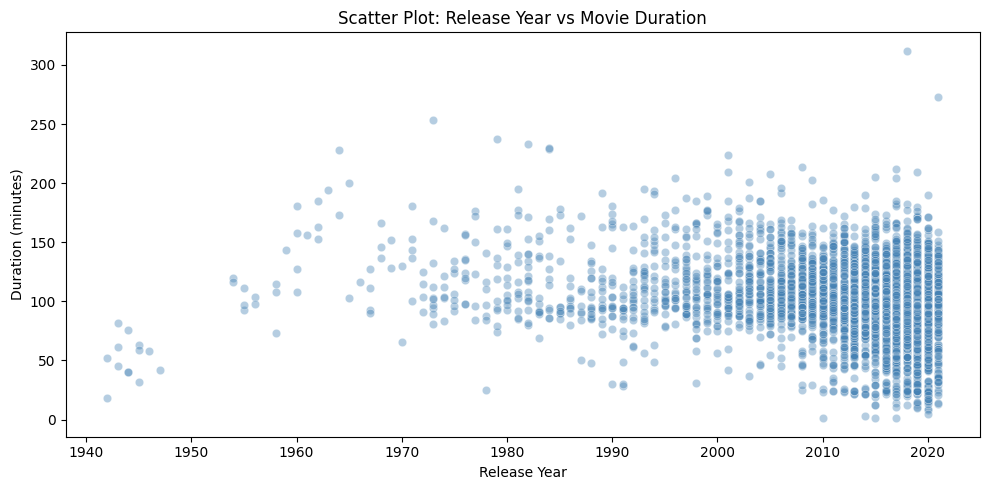


── Task 2 Analysis ──
  Look at the scatter plot:
  - Recent years have MORE dots → more content added lately.
  - Duration seems fairly stable (80–120 min range).
  - No strong upward/downward trend in duration over years.


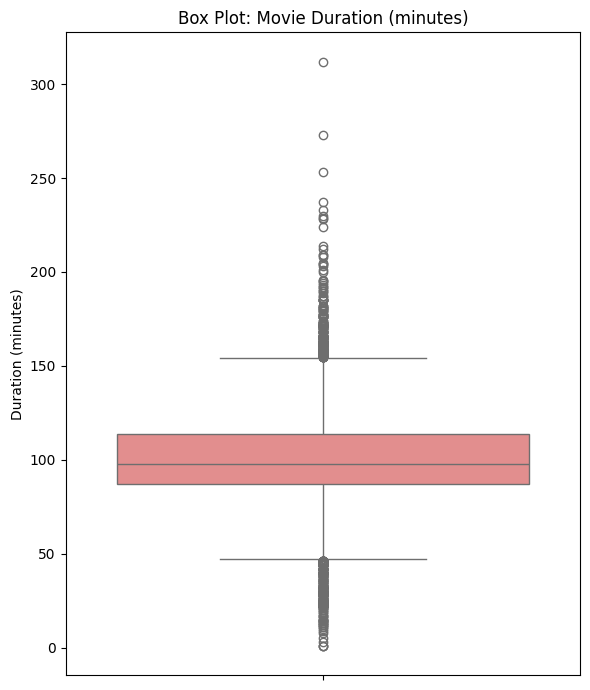


── Task 3 Analysis ──
  Median Duration : 98 min
  Q1              : 87 min
  Q3              : 114 min
  IQR             : 27 min
  Lower fence     : 46 min
  Upper fence     : 154 min
  Number of outliers: 453
  Outliers represent very short films (e.g. documentaries,
  stand-up specials) or very long films (epics, extended cuts).
  Most movies are → MEDIUM (80–120 min)


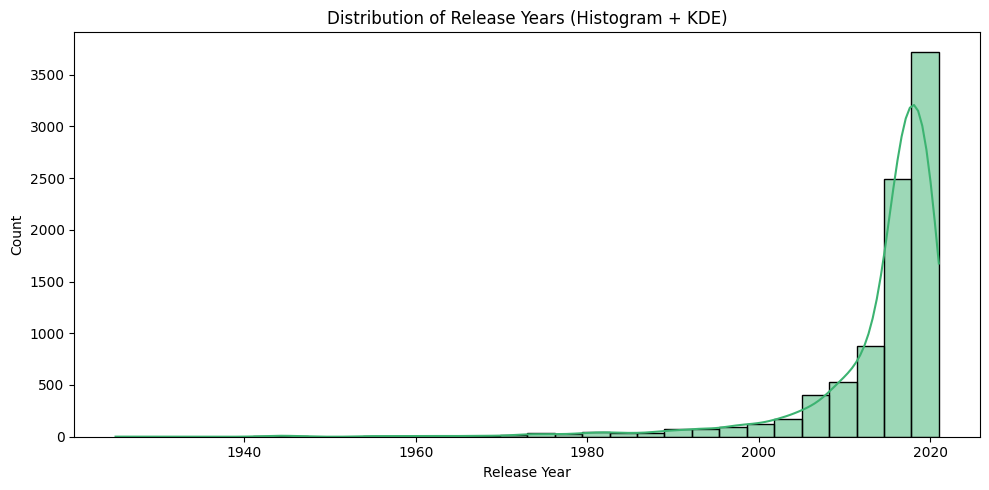


── Task 4 Analysis ──
  Skewness : -3.45
  Distribution is LEFT-SKEWED (negatively skewed).
  Most content is from recent years; older content is sparse.
  Peak year (most content released): 2018

── Task 5: Top 5 Countries ──
country
United States     4520
India             1046
United Kingdom     804
Canada             445
France             393


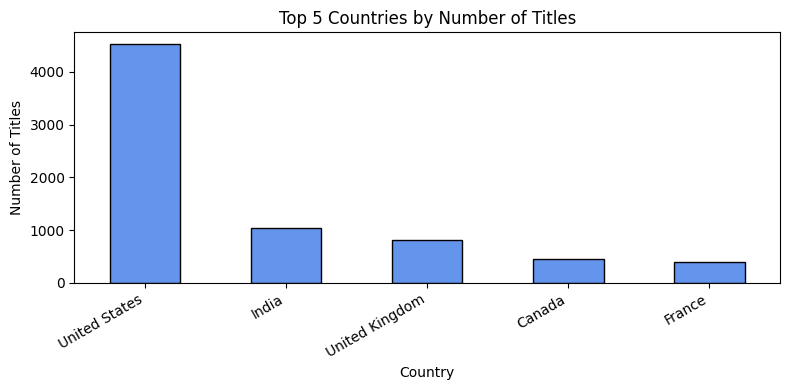


── Task 6: TV Shows After 2020 ──
  Number of TV shows released after 2020 : 315
  Average number of seasons              : 1.72


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ─────────────────────────────────────────────
# Load Dataset
# ─────────────────────────────────────────────
df = pd.read_csv("netflix_movies (1).csv")   # ← change filename if needed
print("Dataset loaded:", df.shape)


# ═══════════════════════════════════════════════════════════
# TASK 7 — Impute Missing Values (done first so clean data
#           is used in all other tasks)
# ═══════════════════════════════════════════════════════════

# 1. Define the text columns
text_cols = ['director', 'cast', 'country', 'date_added', 'rating', 'duration']

# 2. Fill missing values using the first mode of each column
for col in text_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# 3. Fill numeric columns with median
num_cols = df.select_dtypes(include='number').columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

print("\n── Missing Values AFTER imputation ──")
print(df.isnull().sum())

# ─────────────────────────────────────────────
# Helper: extract numeric minutes from 'duration'
# Examples: "90 min" → 90,  "3 Seasons" → stays NaN for movies filter
# ─────────────────────────────────────────────
df['duration_int'] = df['duration'].str.extract(r'(\d+)').astype(float)

# Separate movies and TV shows
movies = df[df['type'] == 'Movie'].copy()
tv     = df[df['type'] == 'TV Show'].copy()


# ═══════════════════════════════════════════════════════════
# TASK 1 — Descriptive Statistics
# ═══════════════════════════════════════════════════════════
print("\n\n══ Task 1: Descriptive Statistics ══")

columns_to_analyse = {
    'release_year' : df['release_year'],
    'duration(min)': movies['duration_int'],   # movies only
    'rating'       : df['rating'],
}

for col_name, series in columns_to_analyse.items():
    print(f"\n── {col_name} ──")
    if series.dtype == object:          # categorical (rating)
        print(f"  Mode   : {series.mode()[0]}")
        print("  (mean/median/std not applicable for text column)")
    else:
        print(f"  Mean   : {series.mean():.2f}")
        print(f"  Median : {series.median():.2f}")
        print(f"  Mode   : {series.mode()[0]:.2f}")
        print(f"  Std Dev: {series.std():.2f}")

# Which feature has highest variability?
print("\n── Variability Comparison ──")
print(f"  release_year std : {df['release_year'].std():.2f}")
print(f"  duration(min) std: {movies['duration_int'].std():.2f}")
print("  → 'duration' usually has the highest variability because")
print("    movie lengths range widely (from short films ~30 min")
print("    to long films ~200+ min), while most content was")
print("    released in a narrow recent range of years.")


# ═══════════════════════════════════════════════════════════
# TASK 2 — Scatter Plot: release_year vs duration
# ═══════════════════════════════════════════════════════════
plt.figure(figsize=(10, 5))
sns.scatterplot(data=movies, x='release_year', y='duration_int',
                alpha=0.4, color='steelblue')
plt.title("Scatter Plot: Release Year vs Movie Duration")
plt.xlabel("Release Year")
plt.ylabel("Duration (minutes)")
plt.tight_layout()
plt.savefig("task2_scatter.png", dpi=150)
plt.show()
print("\n── Task 2 Analysis ──")
print("  Look at the scatter plot:")
print("  - Recent years have MORE dots → more content added lately.")
print("  - Duration seems fairly stable (80–120 min range).")
print("  - No strong upward/downward trend in duration over years.")


# ═══════════════════════════════════════════════════════════
# TASK 3 — Box Plot: Movie Duration
# ═══════════════════════════════════════════════════════════
plt.figure(figsize=(6, 7))
sns.boxplot(y=movies['duration_int'], color='lightcoral')
plt.title("Box Plot: Movie Duration (minutes)")
plt.ylabel("Duration (minutes)")
plt.tight_layout()
plt.savefig("task3_boxplot.png", dpi=150)
plt.show()

Q1  = movies['duration_int'].quantile(0.25)
Q3  = movies['duration_int'].quantile(0.75)
IQR = Q3 - Q1
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR
outliers    = movies[(movies['duration_int'] < lower_fence) |
                     (movies['duration_int'] > upper_fence)]

print("\n── Task 3 Analysis ──")
print(f"  Median Duration : {movies['duration_int'].median():.0f} min")
print(f"  Q1              : {Q1:.0f} min")
print(f"  Q3              : {Q3:.0f} min")
print(f"  IQR             : {IQR:.0f} min")
print(f"  Lower fence     : {lower_fence:.0f} min")
print(f"  Upper fence     : {upper_fence:.0f} min")
print(f"  Number of outliers: {len(outliers)}")
print("  Outliers represent very short films (e.g. documentaries,")
print("  stand-up specials) or very long films (epics, extended cuts).")
median_dur = movies['duration_int'].median()
if median_dur < 80:
    verdict = "SHORT (< 80 min)"
elif median_dur <= 120:
    verdict = "MEDIUM (80–120 min)"
else:
    verdict = "LONG (> 120 min)"
print(f"  Most movies are → {verdict}")


# ═══════════════════════════════════════════════════════════
# TASK 4 — Histogram + KDE: release_year
# ═══════════════════════════════════════════════════════════
plt.figure(figsize=(10, 5))
sns.histplot(df['release_year'], kde=True, bins=30, color='mediumseagreen')
plt.title("Distribution of Release Years (Histogram + KDE)")
plt.xlabel("Release Year")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("task4_histogram.png", dpi=150)
plt.show()

skewness = df['release_year'].skew()
peak_year = int(df['release_year'].mode()[0])
print("\n── Task 4 Analysis ──")
print(f"  Skewness : {skewness:.2f}")
if skewness < -0.5:
    print("  Distribution is LEFT-SKEWED (negatively skewed).")
    print("  Most content is from recent years; older content is sparse.")
elif skewness > 0.5:
    print("  Distribution is RIGHT-SKEWED (positively skewed).")
else:
    print("  Distribution is approximately NORMAL.")
print(f"  Peak year (most content released): {peak_year}")


# ═══════════════════════════════════════════════════════════
# TASK 5 — Top 5 Countries by Content Count
# ═══════════════════════════════════════════════════════════
# Some rows have multiple countries separated by comma → explode them
country_series = (df['country']
                  .str.split(', ')
                  .explode()
                  .str.strip())
top5 = (country_series[country_series != 'Unknown']
        .value_counts()
        .head(5))

print("\n── Task 5: Top 5 Countries ──")
print(top5.to_string())

plt.figure(figsize=(8, 4))
top5.plot(kind='bar', color='cornflowerblue', edgecolor='black')
plt.title("Top 5 Countries by Number of Titles")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig("task5_countries.png", dpi=150)
plt.show()


# ═══════════════════════════════════════════════════════════
# TASK 6 — TV Shows Released After 2020 → Average Seasons
# ═══════════════════════════════════════════════════════════
tv_after_2020 = tv[tv['release_year'] > 2020].copy()

# 'duration' for TV shows looks like "2 Seasons" → extract the number
tv_after_2020['seasons'] = (tv_after_2020['duration']
                            .str.extract(r'(\d+)')
                            .astype(float))

avg_seasons = tv_after_2020['seasons'].mean()
print("\n── Task 6: TV Shows After 2020 ──")
print(f"  Number of TV shows released after 2020 : {len(tv_after_2020)}")
print(f"  Average number of seasons              : {avg_seasons:.2f}")

